<a href="https://colab.research.google.com/github/NehaSanjana24/Sales-Revenue-Analysis-Dashboard/blob/main/Sales_%26_Revenue_Analysis_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sales & Revenue Analysis Dashboard

First, let's upload your sales data. Please run the following cell to upload your CSV file.

## Data Preparation

First, let's ensure the 'Date' column is in datetime format and extract useful time-based features like Month and Year for our analysis.

In [ ]:
# Convert 'Date' column to datetime objects
df['Date'] = pd.to_datetime(df['Date'])

# Extract Month and Year for further analysis
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

# Display the DataFrame info to check data types and ensure no missing values
print(df.info())

display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   Date        15 non-null     datetime64[ns]
 1   Product     15 non-null     object        
 2   Category    15 non-null     object        
 3   Quantity    15 non-null     int64         
 4   Unit_Price  15 non-null     int64         
 5   Revenue     15 non-null     int64         
 6   Month       15 non-null     int32         
 7   Year        15 non-null     int32         
dtypes: datetime64[ns](1), int32(2), int64(3), object(2)
memory usage: 972.0+ bytes
None


,Date,Product,Category,Quantity,Unit_Price,Revenue,Month,Year
0,2026-01-15,Laptop,Computing,2,1200,2400,1,2026
1,2026-01-18,Smartphone,Mobile,5,800,4000,1,2026
2,2026-02-02,Wireless Headphones,Audio,10,150,1500,2,2026
3,2026-02-12,Smartwatch,Wearables,4,250,1000,2,2026
4,2026-02-25,Tablet,Computing,3,450,1350,2,2026


## Key Performance Indicators (KPIs)

Let's calculate some basic KPIs to get an overview of our sales data, such as Total Revenue and Total Quantity Sold.

In [ ]:
# Calculate Total Revenue
total_revenue = df['Revenue'].sum()

# Calculate Total Quantity Sold
total_quantity_sold = df['Quantity'].sum()

# Display the KPIs
print(f"Total Revenue: ${total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity_sold}")

Total Revenue: $30,550.00
Total Quantity Sold: 73


## Sales Trend Analysis

Let's visualize the revenue trend over time to identify any patterns or seasonality. A monthly revenue line chart will be helpful for this.

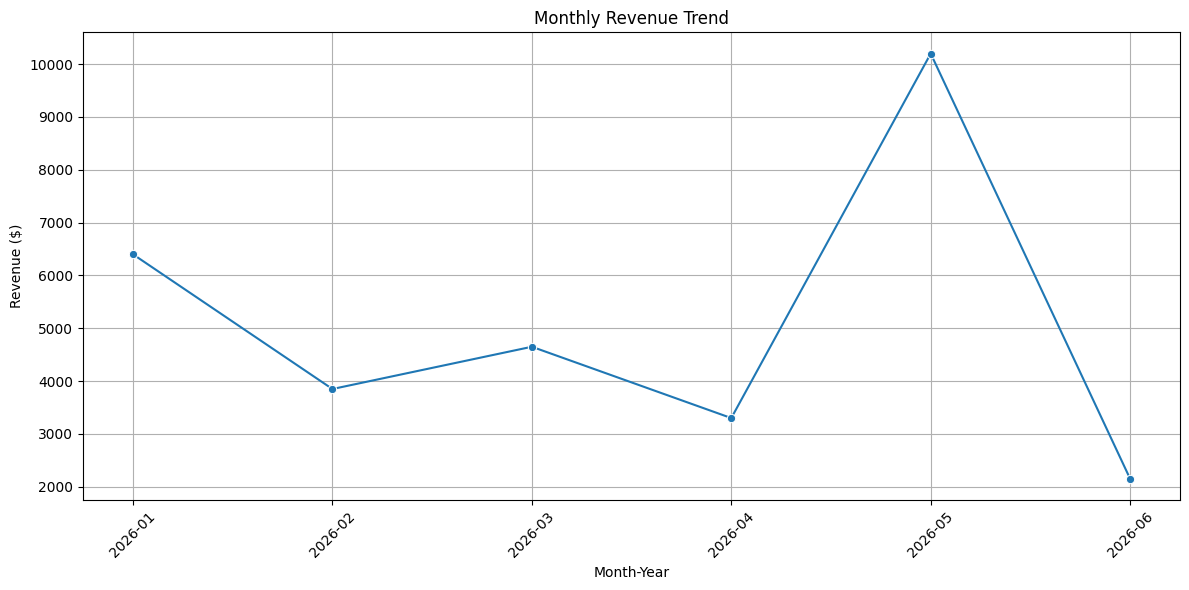

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by Year and Month to get monthly revenue
monthly_revenue = df.groupby(['Year', 'Month'])['Revenue'].sum().reset_index()

# Create a 'Month_Year' column for better plotting labels
monthly_revenue['Month_Year'] = monthly_revenue['Year'].astype(str) + '-' + monthly_revenue['Month'].astype(str).str.zfill(2)

# Sort by date for correct plotting order
monthly_revenue = monthly_revenue.sort_values(by=['Year', 'Month'])

plt.figure(figsize=(12, 6))
sns.lineplot(x='Month_Year', y='Revenue', data=monthly_revenue, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month-Year')
plt.ylabel('Revenue ($)')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Product Category Performance

Let's analyze the total revenue generated by each product category to identify top-performing categories.

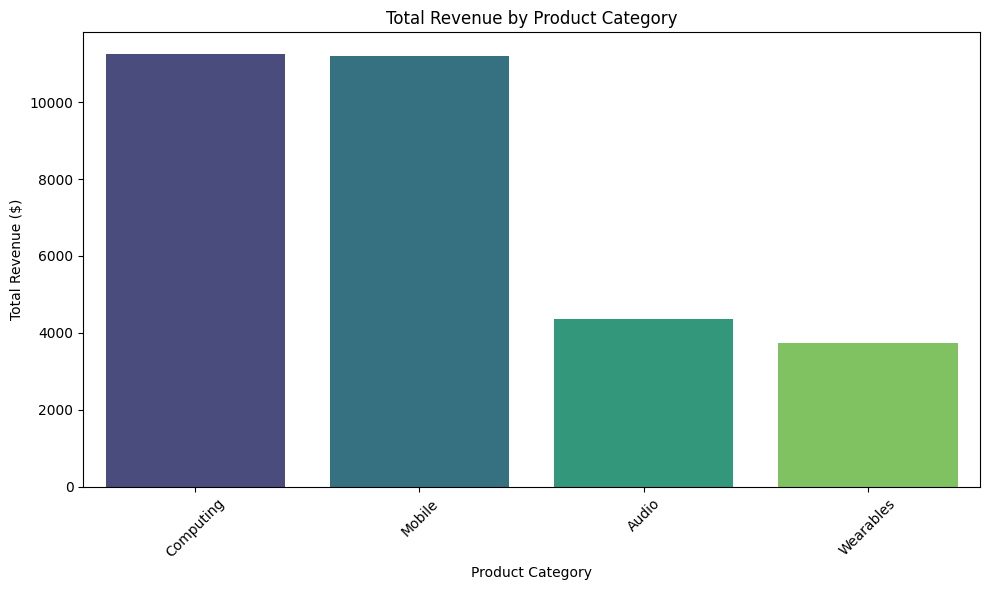

In [ ]:
# Group by Category and sum Revenue
category_revenue = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Category', y='Revenue', hue='Category', data=category_revenue, palette='viridis', legend=False)
plt.title('Total Revenue by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Top Performing Products

Let's identify the top products by total revenue to understand which products are driving sales.

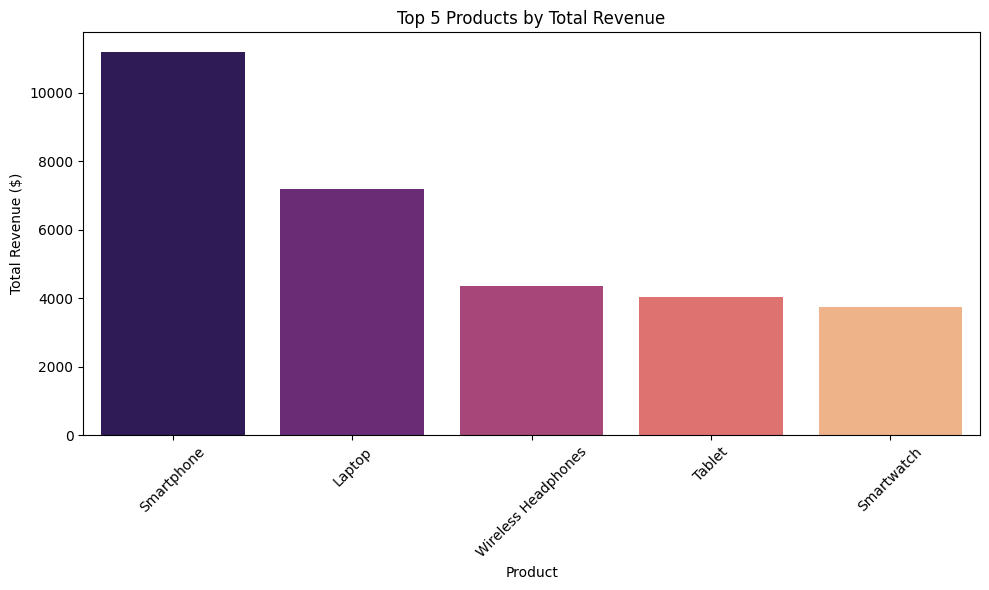

In [ ]:
# Group by Product and sum Revenue, then sort and take the top N (e.g., top 5)
top_products = df.groupby('Product')['Revenue'].sum().sort_values(ascending=False).head(5).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Product', y='Revenue', hue='Product', data=top_products, palette='magma', legend=False)
plt.title('Top 5 Products by Total Revenue')
plt.xlabel('Product')
plt.ylabel('Total Revenue ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Product Sales Volume

Let's analyze the total quantity of each product sold to complement our revenue analysis. This helps in understanding sales volume independent of price.

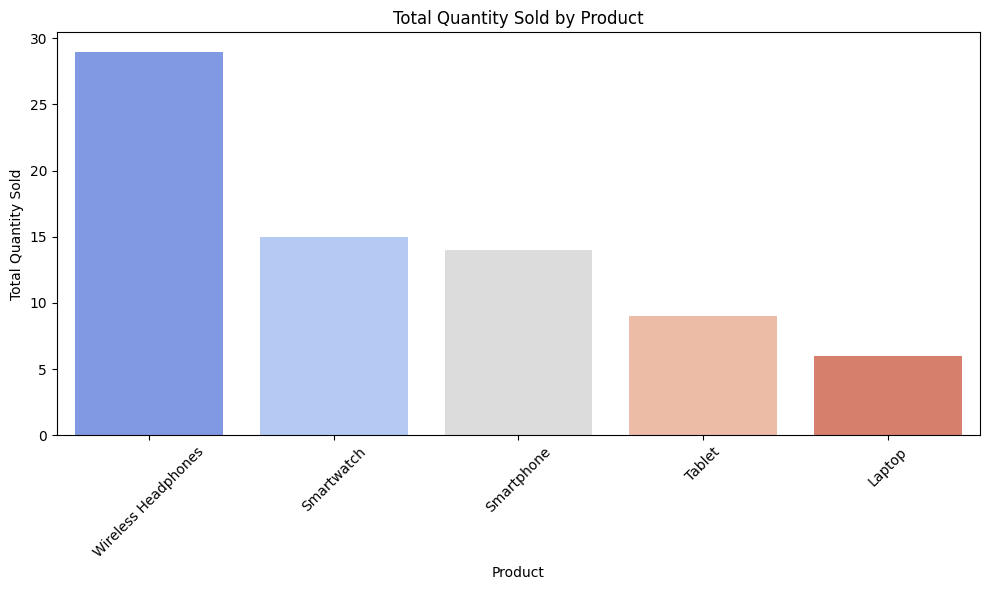

In [ ]:
# Group by Product and sum Quantity, then sort
product_quantity = df.groupby('Product')['Quantity'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='Product', y='Quantity', hue='Product', data=product_quantity, palette='coolwarm', legend=False)
plt.title('Total Quantity Sold by Product')
plt.xlabel('Product')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()